In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [60]:

data=pd.read_csv('CleanData.csv')


# UNIVARIATE EDA


In [4]:
# Count of each class
data["is_fake"].value_counts()

is_fake
0    1528
1    1472
Name: count, dtype: int64

In [5]:
# Percentage of each class
data["is_fake"].value_counts(normalize=True) * 100

is_fake
0    50.933333
1    49.066667
Name: proportion, dtype: float64

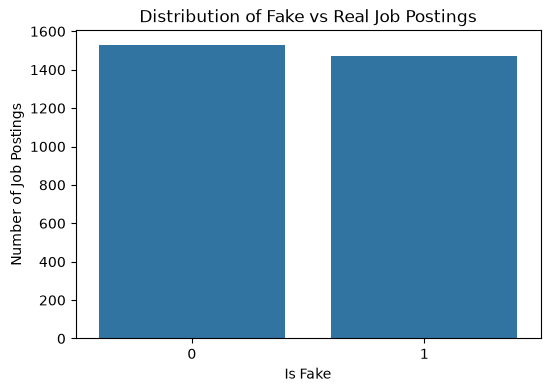

In [6]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=data,
    x="is_fake"
)

plt.title("Distribution of Fake vs Real Job Postings")
plt.xlabel("Is Fake")
plt.ylabel("Number of Job Postings")

plt.show()

In [7]:
# Summary statistics for numerical columns
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,3000.0,1499.500000,866.169729,0.0,749.75,1499.5,2249.25,2999.0
required_experience_years,3000.0,5.044000,3.168292,0.0,2.00,5.0,8.00,10.0
has_logo,3000.0,0.246000,0.430750,0.0,0.00,0.0,0.00,1.0
num_open_positions,3000.0,5.564000,2.890102,1.0,3.00,6.0,8.00,10.0
telecommuting,3000.0,0.507667,0.500025,0.0,0.00,1.0,1.00,1.0
text_length,3000.0,79.186667,9.999924,69.0,69.00,89.0,89.00,89.0
is_fake,3000.0,0.490667,0.499996,0.0,0.00,0.0,1.00,1.0


In [8]:
data.head()

,Unnamed: 0,job_title,job_description,requirements,benefits,company_profile,industry,employment_type,salary_range,required_experience_years,...,department,posting_date,contact_email,has_logo,num_open_positions,job_function,telecommuting,text_length,is_fake,application_deadline
0,0,Software Engineer,We are looking for responsibilities fast-paced...,Candidates should have dynamic team skills fas...,We offer required skills fast-paced skills req...,Our company growth fast-paced responsibilities...,Marketing,Contract,$60k-$80k,8,...,Sales,2023-11-24,hr312@company.com,0,3,Management,0,89,0,2024-09-16
1,1,Content Writer,We are looking for required support experience...,Candidates should have required team fast-pace...,We offer fast-paced dynamic dynamic strategy g...,Our company fast-paced opportunity innovation ...,Finance,Full-time,$40k-$60k,10,...,HR,2023-03-03,hr127@company.com,0,10,Development,1,89,0,2024-10-18
2,2,Customer Support Specialist,We are looking for dynamic required fast-paced...,Candidates should have preferred knowledge opp...,We offer skills experience required growth res...,We are global innovation growth skills knowled...,Healthcare,Internship,$60k-$80k,3,...,Marketing,2023-07-31,job92@gmail.com,0,6,Support,0,69,1,2024-01-13
3,3,Data Analyst,We are looking for collaboration skills suppor...,Candidates should have innovation team require...,We offer strategy strategy dynamic support opp...,Our company fast-paced support team strategy i...,Healthcare,Part-time,Not Disclosed,10,...,Sales,2023-08-14,hr366@company.com,1,4,Management,1,89,0,2024-02-09
4,4,Graphic Designer,We are looking for team growth growth fast-pac...,Candidates should have experience preferred kn...,We offer opportunity skills responsibilities c...,We are global experience skills preferred fast...,Retail,Part-time,$60k-$80k,7,...,Design,2023-04-22,job359@gmail.com,0,5,Management,0,69,1,2024-08-26


In [36]:
data.drop(columns="Unnamed: 0", inplace=True)

In [14]:
data["text_length"].value_counts().sort_index()

text_length
69    1472
89    1528
Name: count, dtype: int64

In [16]:
# Numerical columns
numerical_columns = data.select_dtypes(include=["number"]).columns.tolist()

# Categorical columns
categorical_columns = data.select_dtypes(include=["str"]).columns.tolist()

# Datetime columns
datetime_columns = data.select_dtypes(include=["datetime"]).columns.tolist()

print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

print("\nDatetime Columns:")
print(datetime_columns)

Numerical Columns:
['required_experience_years', 'has_logo', 'num_open_positions', 'telecommuting', 'text_length', 'is_fake']

Categorical Columns:
['job_title', 'job_description', 'requirements', 'benefits', 'company_profile', 'industry', 'employment_type', 'salary_range', 'education_level', 'department', 'posting_date', 'contact_email', 'job_function', 'application_deadline']

Datetime Columns:
[]


In [17]:
# Convert date columns back to datetime
data["posting_date"] = pd.to_datetime(data["posting_date"])
data["application_deadline"] = pd.to_datetime(data["application_deadline"])

In [56]:
data = data.drop(columns="text_length") # column has low variability and rellevance 


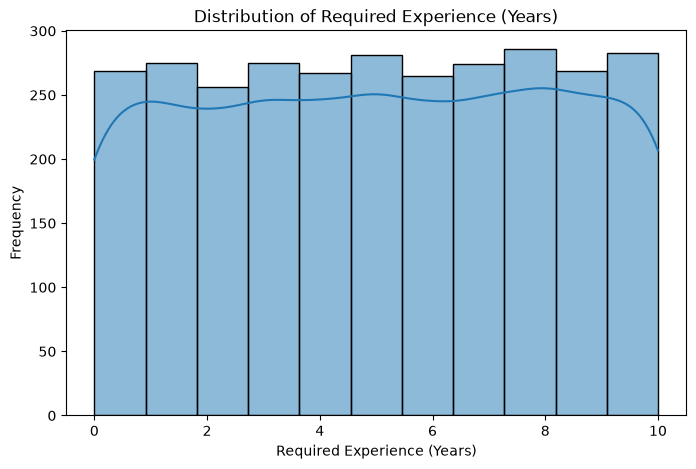

In [19]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=data,
    x="required_experience_years",
    bins=11,
    kde=True
)

plt.title("Distribution of Required Experience (Years)")
plt.xlabel("Required Experience (Years)")
plt.ylabel("Frequency")

plt.show()

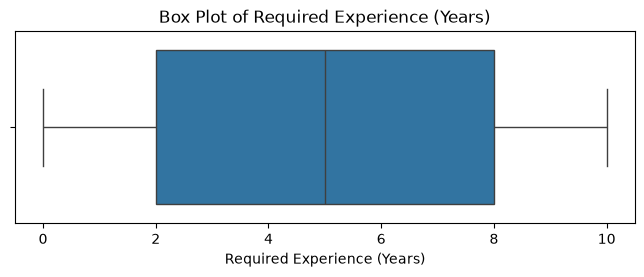

In [20]:
plt.figure(figsize=(8, 2.5))

sns.boxplot(
    data=data,
    x="required_experience_years"
)

plt.title("Box Plot of Required Experience (Years)")
plt.xlabel("Required Experience (Years)")

plt.show()

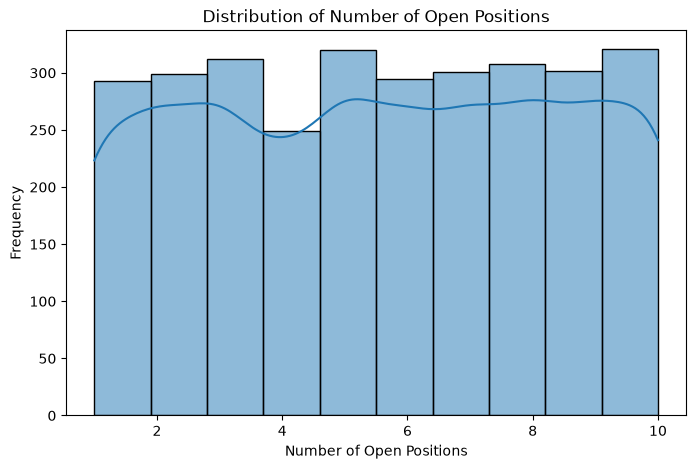

In [21]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=data,
    x="num_open_positions",
    bins=10,
    kde=True
)

plt.title("Distribution of Number of Open Positions")
plt.xlabel("Number of Open Positions")
plt.ylabel("Frequency")

plt.show()

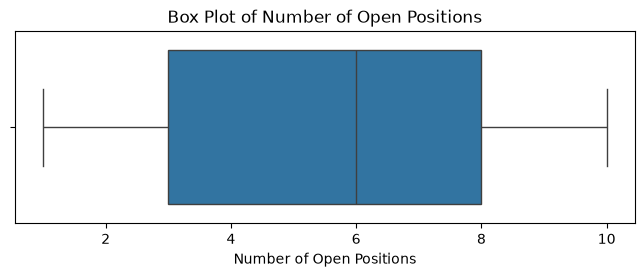

In [22]:
plt.figure(figsize=(8, 2.5))

sns.boxplot(
    data=data,
    x="num_open_positions"
)

plt.title("Box Plot of Number of Open Positions")
plt.xlabel("Number of Open Positions")

plt.show()

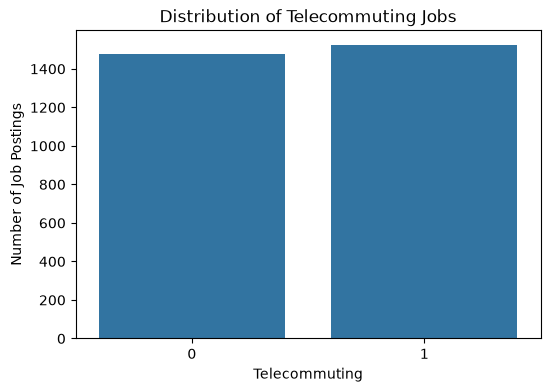

In [23]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=data,
    x="telecommuting"
)

plt.title("Distribution of Telecommuting Jobs")
plt.xlabel("Telecommuting")
plt.ylabel("Number of Job Postings")

plt.show()


In [24]:
data["telecommuting"].value_counts(normalize=True) * 100

telecommuting
1    50.766667
0    49.233333
Name: proportion, dtype: float64

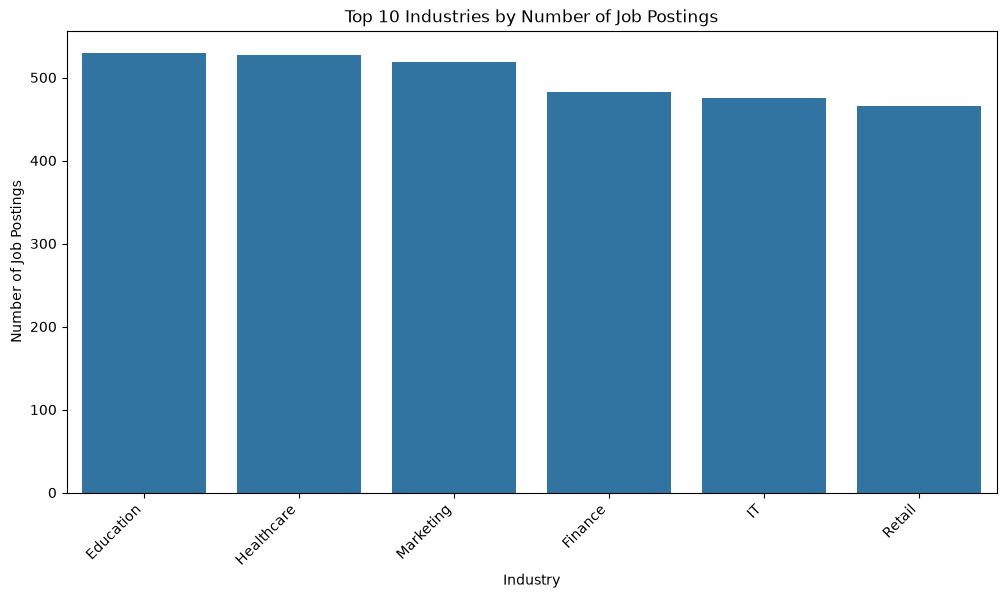

In [25]:
plt.figure(figsize=(12, 6))

top_industries = data["industry"].value_counts().head(10)

sns.barplot(
    x=top_industries.index,
    y=top_industries.values
)

plt.title("Top 10 Industries by Number of Job Postings")
plt.xlabel("Industry")
plt.ylabel("Number of Job Postings")

plt.xticks(rotation=45, ha="right")

plt.show()

In [27]:
top_industries = data["industry"].value_counts().head(10)
top_industries

industry
Education     530
Healthcare    527
Marketing     519
Finance       483
IT            475
Retail        466
Name: count, dtype: int64

In [28]:
data["employment_type"].value_counts()

employment_type
Part-time     615
Full-time     614
Internship    605
Contract      598
Temporary     568
Name: count, dtype: int64

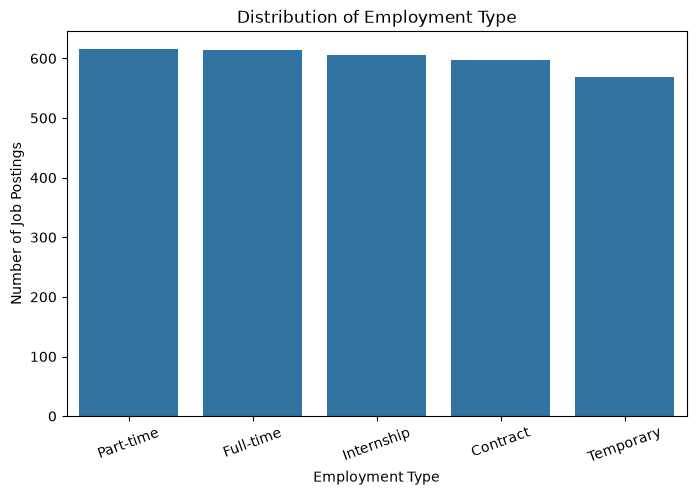

In [29]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=data,
    x="employment_type",
    order=data["employment_type"].value_counts().index
)

plt.title("Distribution of Employment Type")
plt.xlabel("Employment Type")
plt.ylabel("Number of Job Postings")

plt.xticks(rotation=20)

plt.show()


# Bivariate EDA 


In [30]:
industry_fraud = pd.crosstab(
    data["industry"],
    data["is_fake"]
)

industry_fraud

is_fake,0,1
industry,,
Education,273,257
Finance,245,238
Healthcare,261,266
IT,250,225
Marketing,265,254
Retail,234,232


In [32]:
industry_fraud_pct = pd.crosstab(
    data["industry"],
    data["is_fake"],
    normalize="index"
) * 100

industry_fraud_pct

is_fake,0,1
industry,,
Education,51.509434,48.490566
Finance,50.724638,49.275362
Healthcare,49.525617,50.474383
IT,52.631579,47.368421
Marketing,51.059730,48.940270
Retail,50.214592,49.785408


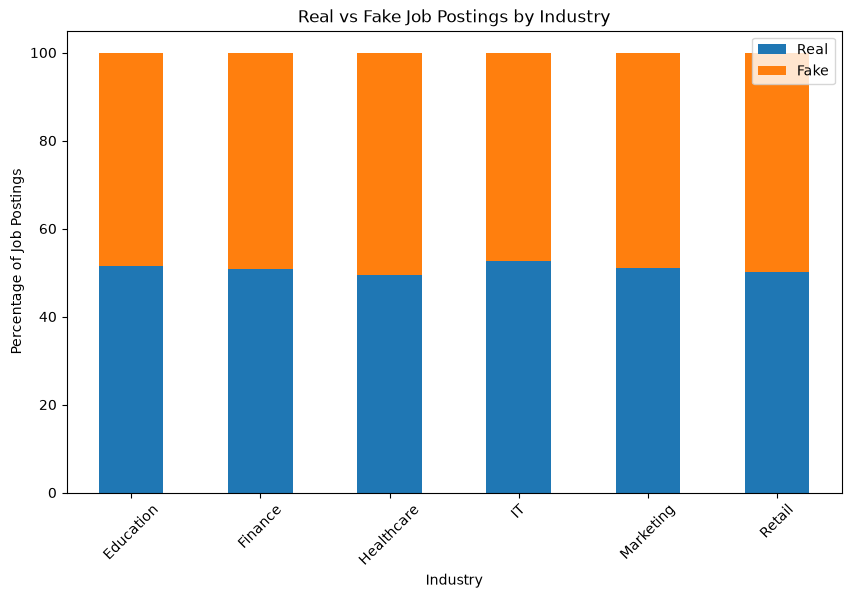

In [33]:
industry_fraud_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Real vs Fake Job Postings by Industry")
plt.xlabel("Industry")
plt.ylabel("Percentage of Job Postings")
plt.legend(["Real", "Fake"])

plt.xticks(rotation=45)
plt.show()

# CORRELATION ANALYSIS

In [50]:
# Select only numerical columns
numerical_data = data.select_dtypes(include=["number"])

# Compute correlation matrix
corr_matrix = numerical_data.corr()

corr_matrix

,Unnamed: 0,required_experience_years,has_logo,num_open_positions,telecommuting,is_fake
Unnamed: 0,1.000000,0.009487,-0.011002,0.002299,0.016006,-0.000024
required_experience_years,0.009487,1.000000,-0.031634,-0.026490,-0.005264,0.002996
has_logo,-0.011002,-0.031634,1.000000,0.022973,-0.021144,-0.560627
num_open_positions,0.002299,-0.026490,0.022973,1.000000,-0.020068,-0.021046
telecommuting,0.016006,-0.005264,-0.021144,-0.020068,1.000000,0.020959
is_fake,-0.000024,0.002996,-0.560627,-0.021046,0.020959,1.000000


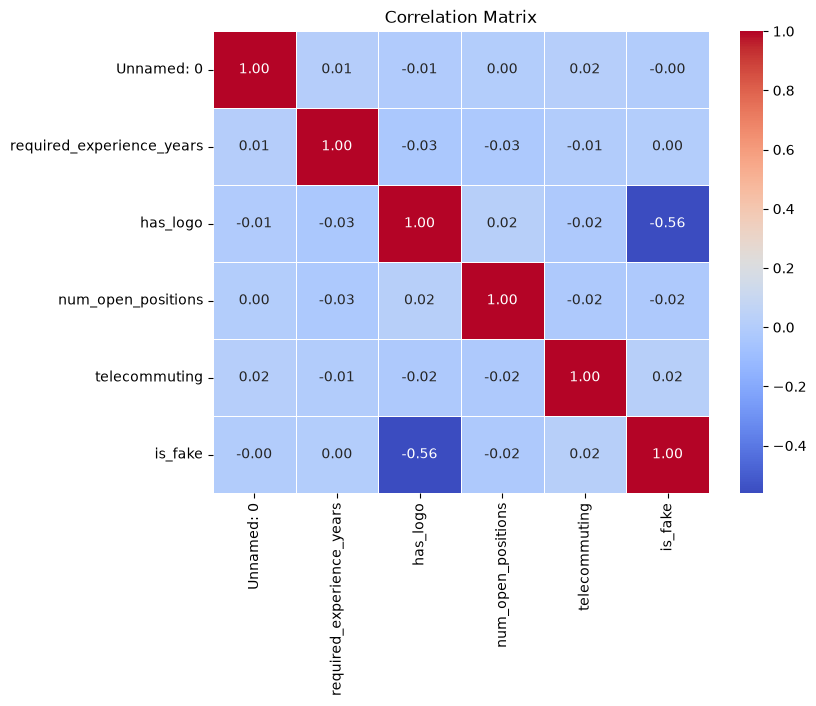

In [51]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.show()

In [61]:
data.drop(columns="Unnamed: 0", inplace=True)

# Save the cleaned dataset
data.to_csv('CleanData.csv', index=False)